# Single Unit: The PFR (Plug Flow Reactor)

**Prerequisites:** [00d_single_unit_cstr](./00d_single_unit_cstr.ipynb), [00e_energy_balances](./00e_single_unit_energy_balances.ipynb)

**Learning Objectives:**
- Derive the PFR design equation (an ODE, not algebraic!)
- Understand the key difference between CSTR and PFR
- Implement PFR integration from scratch
- Compare CSTR vs PFR performance

---

## What is a PFR?

A **Plug Flow Reactor (PFR)** is a tubular reactor where:
- Reactants flow through in "plugs" with no mixing in the flow direction
- Perfect radial mixing (uniform composition across the tube cross-section)
- Composition changes continuously along the length

```
  Inlet                                              Outlet
  ──────╦══════════════════════════════════════════╦──────►
        ║  →  →  →  →  →  →  →  →  →  →  →  →  →  ║
        ║  Concentration decreases along length   ║
        ║  →  →  →  →  →  →  →  →  →  →  →  →  →  ║
  ──────╩══════════════════════════════════════════╩──────
        x=0                                      x=L
```

**Key difference from CSTR:** In a PFR, concentration varies with position. In a CSTR, concentration is uniform everywhere.

## Deriving the PFR Design Equation

Consider a differential volume element $dV$ in the reactor:

$$\text{(Moles of } i \text{ in)} - \text{(Moles of } i \text{ out)} + \text{(Generation)} = 0$$

$$F_i - (F_i + dF_i) + r_i \cdot dV = 0$$

$$dF_i = r_i \cdot dV$$

$$\boxed{\frac{dF_i}{dV} = r_i}$$

This is an **ordinary differential equation (ODE)**, not an algebraic equation like the CSTR.

### For First-Order Reaction A → B

$$\frac{dF_A}{dV} = -k C_A = -k \frac{F_A}{Q}$$

This is a separable ODE:

$$\int_{F_{A,in}}^{F_{A,out}} \frac{dF_A}{F_A} = -\frac{k}{Q} \int_0^V dV$$

$$\ln\frac{F_{A,out}}{F_{A,in}} = -\frac{kV}{Q} = -k\tau$$

$$\boxed{F_{A,out} = F_{A,in} \cdot e^{-k\tau}}$$

$$\boxed{X = 1 - e^{-k\tau}}$$

In [1]:
# Setup
import jax.numpy as jnp
import jax
from jax import lax
jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
import numpy as np

from difflow import PFR, PFRParams, CSTR, CSTRParams, make_stream, get_flows, IdealThermo, SpeciesData

In [2]:
# Problem setup: First-order reaction A -> B

k = 0.5        # Rate constant, 1/s
F_A_in = 10.0  # Inlet flow of A, mol/s
V = 2.0        # Reactor volume, m³
Q = 0.2        # Volumetric flow rate, m³/s
tau = V / Q    # Residence time, s

print("PFR Problem Setup")
print("=" * 40)
print(f"Reaction: A → B (first-order, k = {k} /s)")
print(f"Feed: F_A = {F_A_in} mol/s")
print(f"Volume: V = {V} m³")
print(f"Flow rate: Q = {Q} m³/s")
print(f"Residence time: τ = {tau} s")
print(f"Damköhler number: Da = kτ = {k*tau}")

PFR Problem Setup
Reaction: A → B (first-order, k = 0.5 /s)
Feed: F_A = 10.0 mol/s
Volume: V = 2.0 m³
Flow rate: Q = 0.2 m³/s
Residence time: τ = 10.0 s
Damköhler number: Da = kτ = 5.0


In [3]:
# Analytical solution for first-order PFR

F_A_out_analytical = F_A_in * np.exp(-k * tau)
X_analytical = 1 - np.exp(-k * tau)

print("Analytical Solution (First-Order PFR)")
print("=" * 40)
print(f"F_A_out = F_A_in × exp(-kτ) = {F_A_in} × exp(-{k*tau}) = {F_A_out_analytical:.4f} mol/s")
print(f"Conversion X = 1 - exp(-kτ) = 1 - exp(-{k*tau}) = {X_analytical*100:.2f}%")

Analytical Solution (First-Order PFR)
F_A_out = F_A_in × exp(-kτ) = 10.0 × exp(-5.0) = 0.0674 mol/s
Conversion X = 1 - exp(-kτ) = 1 - exp(-5.0) = 99.33%


## Numerical Solution: Using scipy's ODE Solver

For more complex kinetics, we need to integrate the ODE numerically. Python's `scipy.integrate.solve_ivp` provides robust, well-tested ODE solvers:

```python
from scipy.integrate import solve_ivp

solution = solve_ivp(
    fun,           # dy/dt = fun(t, y)
    t_span,        # (t_start, t_end)
    y0,            # Initial conditions
    method='RK45', # Runge-Kutta 4(5) adaptive step size
    dense_output=True,
)
```

For PFR integration, we integrate over volume (not time): $\frac{dF}{dV} = r$

In [4]:
# Numerical solution using scipy's solve_ivp

from scipy.integrate import solve_ivp

def pfr_rhs(V, F, Q, k):
    """
    Right-hand side of PFR design equation.
    dF/dV = [r_A, r_B] where r_A = -k*C_A, r_B = k*C_A
    
    Note: scipy uses (t, y) convention, so V is first argument
    """
    F_A, F_B = F
    C_A = F_A / Q
    r_A = -k * C_A  # Rate of consumption
    r_B = k * C_A   # Rate of production
    return [r_A, r_B]

# Integrate from V=0 to V=V_total
F_in = [F_A_in, 0.0]  # [F_A, F_B]
V_span = (0, V)
n_points = 100
V_eval = np.linspace(0, V, n_points + 1)

solution = solve_ivp(
    pfr_rhs,
    V_span,
    F_in,
    args=(Q, k),
    method='RK45',
    t_eval=V_eval,  # Points where we want solution
    dense_output=True,
)

# Extract results
V_traj = solution.t
F_traj = solution.y.T  # Transpose to get (n_points, n_species)

F_A_out_numerical = F_traj[-1, 0]
X_numerical = (F_A_in - F_A_out_numerical) / F_A_in

print("Numerical Solution (scipy solve_ivp with RK45)")
print("=" * 50)
print(f"F_A_out = {F_A_out_numerical:.4f} mol/s")
print(f"Conversion X = {X_numerical*100:.2f}%")
print(f"")
print(f"Comparison with analytical:")
print(f"  Analytical: X = {X_analytical*100:.4f}%")
print(f"  Numerical:  X = {X_numerical*100:.4f}%")
print(f"  Difference: {abs(X_analytical - X_numerical)*100:.6f}%")

Numerical Solution (scipy solve_ivp with RK45)
F_A_out = 0.0676 mol/s
Conversion X = 99.32%

Comparison with analytical:
  Analytical: X = 99.3262%
  Numerical:  X = 99.3244%
  Difference: 0.001763%


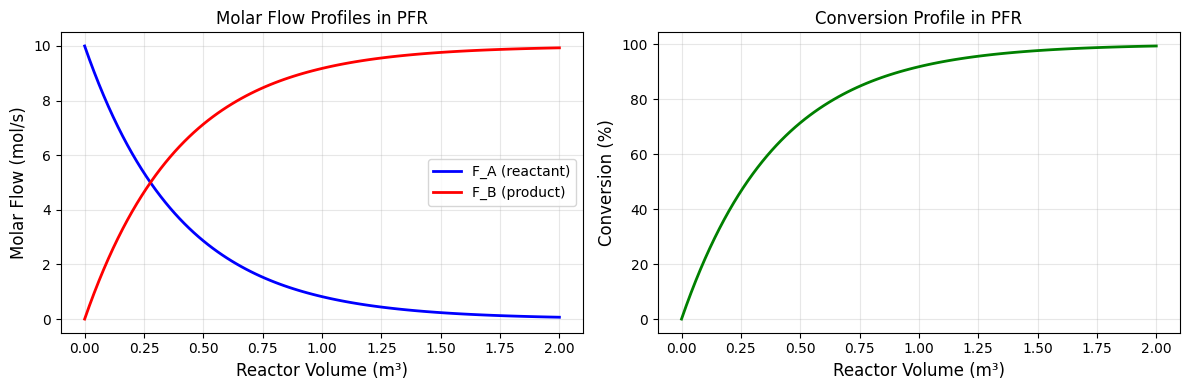

In [5]:
# Visualize concentration profile along the reactor

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Molar flows
ax = axes[0]
ax.plot(V_traj, F_traj[:, 0], 'b-', linewidth=2, label='F_A (reactant)')
ax.plot(V_traj, F_traj[:, 1], 'r-', linewidth=2, label='F_B (product)')
ax.set_xlabel('Reactor Volume (m³)', fontsize=12)
ax.set_ylabel('Molar Flow (mol/s)', fontsize=12)
ax.set_title('Molar Flow Profiles in PFR', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Right: Conversion
ax = axes[1]
X_profile = (F_A_in - F_traj[:, 0]) / F_A_in
ax.plot(V_traj, X_profile * 100, 'g-', linewidth=2)
ax.set_xlabel('Reactor Volume (m³)', fontsize=12)
ax.set_ylabel('Conversion (%)', fontsize=12)
ax.set_title('Conversion Profile in PFR', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()


## Using difflow's PFR

In [6]:
# Define species and thermodynamics
species_data = {
    'A': SpeciesData(name='A', MW=50.0, Cp_coeffs=(50.0, 0, 0, 0),
                    Hvap_coeffs=(30000.0, 0.38, 400.0),
                    antoine_coeffs=(10.0, 2000.0, -40.0)),
    'B': SpeciesData(name='B', MW=50.0, Cp_coeffs=(50.0, 0, 0, 0),
                    Hvap_coeffs=(30000.0, 0.38, 400.0),
                    antoine_coeffs=(10.0, 1800.0, -40.0)),
}
thermo = IdealThermo(species_data)
species_order = ['A', 'B']

# Rate function
def rate_fn(C, T, params):
    return jnp.array([params['k'] * C['A']])

# Stoichiometry: A -> B
stoich = jnp.array([[-1.0], [1.0]])

# Create PFR
pfr_params = PFRParams(
    V=jnp.array(V),
    rate_fn=rate_fn,
    stoich=stoich,
    rate_params={'k': jnp.array(k)},
    species_order=species_order,
    n_save_points=101,
)
pfr = PFR(pfr_params, thermo=thermo, mode='isothermal')

# Create inlet stream and solve
inlet = make_stream({'A': F_A_in, 'B': 0.0}, T=300.0, P=101325.0)
outlet, info = pfr(inlet, T_spec=300.0, volumetric_flow=Q)

print("difflow PFR Solution")
print("=" * 40)
print(f"F_A_out = {float(get_flows(outlet)['A']):.4f} mol/s")
print(f"F_B_out = {float(get_flows(outlet)['B']):.4f} mol/s")
print(f"Conversion X = {float(info['conversion']['A'])*100:.2f}%")

difflow PFR Solution
F_A_out = 0.0674 mol/s
F_B_out = 9.9326 mol/s
Conversion X = 99.33%


## CSTR vs PFR Comparison

For positive-order kinetics, PFR always gives higher conversion than CSTR at the same volume.

**Why?**
- In CSTR: Reaction occurs at LOW outlet concentration (diluted by mixing)
- In PFR: Reaction starts at HIGH inlet concentration, decreasing along the tube

Higher concentration → faster rate → more conversion

In [7]:
# Compare CSTR and PFR at same conditions

cstr_params = CSTRParams(
    V=jnp.array(V),
    rate_fn=rate_fn,
    stoich=stoich,
    rate_params={'k': jnp.array(k)},
    species_order=species_order,
)
cstr = CSTR(cstr_params, thermo=thermo, mode='isothermal')

outlet_cstr, info_cstr = cstr(inlet, T_spec=300.0, volumetric_flow=Q)

print("CSTR vs PFR Comparison")
print("=" * 50)
print(f"Same conditions: V = {V} m³, Q = {Q} m³/s, k = {k} /s")
print(f"Residence time: τ = {tau} s")
print(f"Damköhler number: Da = {k*tau}")
print(f"")
print(f"{'Reactor':<10} {'F_A_out (mol/s)':<20} {'Conversion (%)':<15}")
print("-" * 50)
print(f"{'CSTR':<10} {float(get_flows(outlet_cstr)['A']):<20.4f} {float(info_cstr['conversion']['A'])*100:<15.2f}")
print(f"{'PFR':<10} {float(get_flows(outlet)['A']):<20.4f} {float(info['conversion']['A'])*100:<15.2f}")
print(f"")
print(f"PFR advantage: {(float(info['conversion']['A']) - float(info_cstr['conversion']['A']))*100:.2f} percentage points")

CSTR vs PFR Comparison
Same conditions: V = 2.0 m³, Q = 0.2 m³/s, k = 0.5 /s
Residence time: τ = 10.0 s
Damköhler number: Da = 5.0

Reactor    F_A_out (mol/s)      Conversion (%) 
--------------------------------------------------
CSTR       1.6667               83.33          
PFR        0.0674               99.33          

PFR advantage: 15.99 percentage points


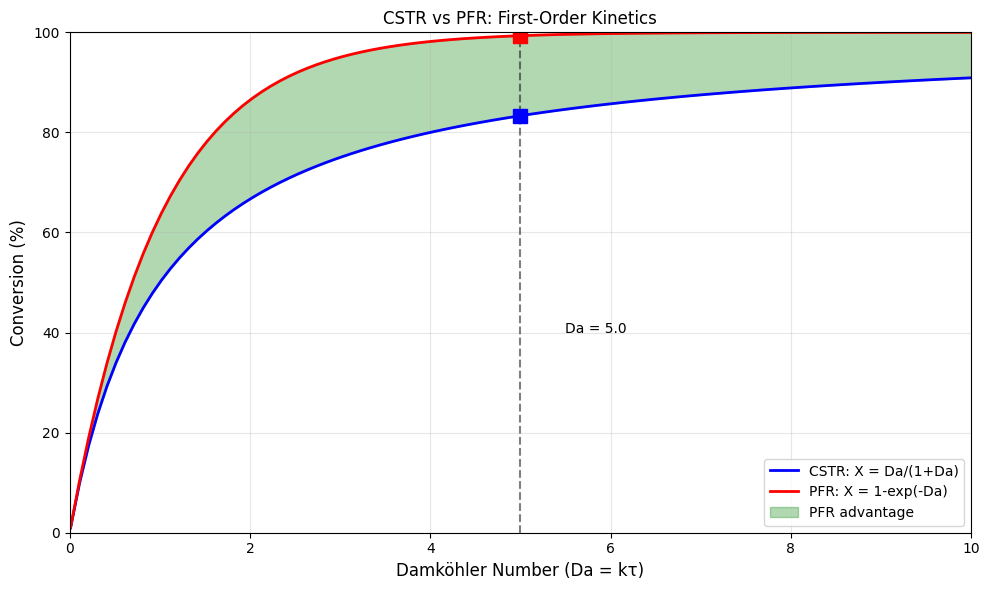

In [8]:
# Plot conversion vs Da for both reactors

Da_range = np.linspace(0.01, 10, 100)
X_cstr = Da_range / (1 + Da_range)
X_pfr = 1 - np.exp(-Da_range)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(Da_range, X_cstr * 100, 'b-', linewidth=2, label='CSTR: X = Da/(1+Da)')
ax.plot(Da_range, X_pfr * 100, 'r-', linewidth=2, label='PFR: X = 1-exp(-Da)')

# Shade the PFR advantage region
ax.fill_between(Da_range, X_cstr*100, X_pfr*100, alpha=0.3, color='green', label='PFR advantage')

# Mark our operating point
ax.axvline(x=k*tau, color='k', linestyle='--', alpha=0.5)
ax.plot(k*tau, float(info_cstr['conversion']['A'])*100, 'bs', markersize=10)
ax.plot(k*tau, float(info['conversion']['A'])*100, 'rs', markersize=10)
ax.annotate(f'Da = {k*tau}', xy=(k*tau, 50), xytext=(k*tau+0.5, 40), fontsize=10)

ax.set_xlabel('Damköhler Number (Da = kτ)', fontsize=12)
ax.set_ylabel('Conversion (%)', fontsize=12)
ax.set_title('CSTR vs PFR: First-Order Kinetics', fontsize=12)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 10)
ax.set_ylim(0, 100)

plt.tight_layout()


## When is the PFR Advantage Largest?

The ratio of reactor volumes needed to achieve the same conversion:

$$\frac{V_{CSTR}}{V_{PFR}} = \frac{X/(1-X)}{-\ln(1-X)}$$

This ratio increases dramatically at high conversions!

Volume Ratio Interpretation:
  At 50% conversion: CSTR needs 1.4× the volume of PFR
  At 90% conversion: CSTR needs 3.9× the volume of PFR
  At 99% conversion: CSTR needs 21.5× the volume of PFR!


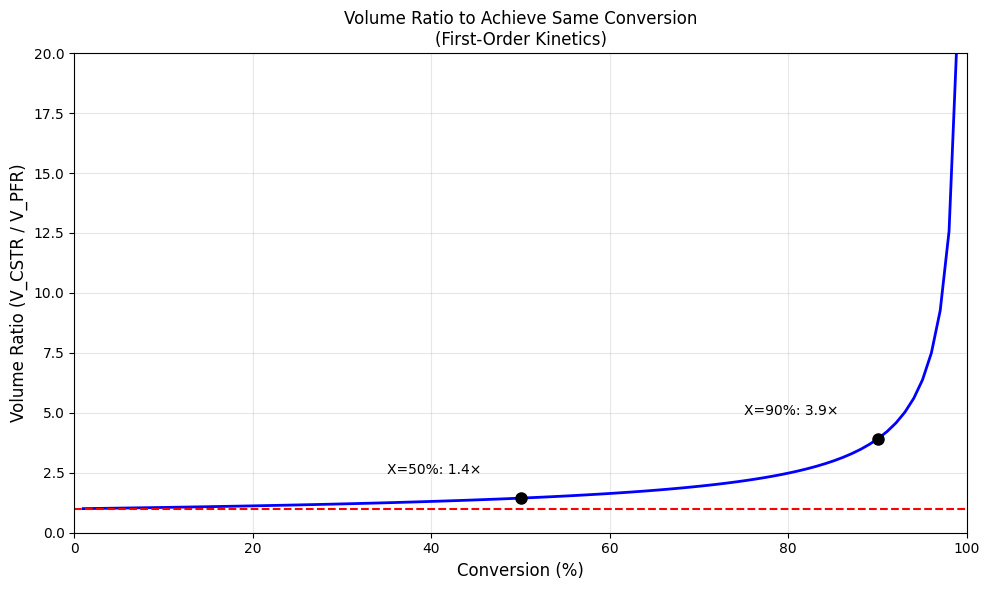

In [9]:
# Volume ratio: V_CSTR / V_PFR for same conversion

X = np.linspace(0.01, 0.99, 100)

# For first-order kinetics:
# CSTR: V/Q = X / (k(1-X))
# PFR:  V/Q = -ln(1-X) / k
# Ratio = X/(1-X) / (-ln(1-X))

volume_ratio = (X / (1 - X)) / (-np.log(1 - X))

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(X * 100, volume_ratio, 'b-', linewidth=2)
ax.axhline(y=1, color='r', linestyle='--', label='Equal volume')

# Highlight key points
for X_point in [0.5, 0.9, 0.99]:
    ratio = (X_point / (1 - X_point)) / (-np.log(1 - X_point))
    ax.plot(X_point * 100, ratio, 'ko', markersize=8)
    ax.annotate(f'X={X_point*100:.0f}%: {ratio:.1f}×', 
                xy=(X_point*100, ratio), xytext=(X_point*100-15, ratio+1),
                fontsize=10)

ax.set_xlabel('Conversion (%)', fontsize=12)
ax.set_ylabel('Volume Ratio (V_CSTR / V_PFR)', fontsize=12)
ax.set_title('Volume Ratio to Achieve Same Conversion\n(First-Order Kinetics)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 100)
ax.set_ylim(0, 20)

plt.tight_layout()

print("Volume Ratio Interpretation:")
print("  At 50% conversion: CSTR needs 1.4× the volume of PFR")
print("  At 90% conversion: CSTR needs 3.9× the volume of PFR")
print("  At 99% conversion: CSTR needs 21.5× the volume of PFR!")

## Try It Yourself!

### Exercise 1: Second-Order Kinetics
Modify the rate function for second-order kinetics: r = k·C_A². Compare CSTR vs PFR. Is the PFR advantage larger or smaller than for first-order?

In [10]:
# Your solution here

### Exercise 2: CSTRs in Series
How many equal-volume CSTRs in series does it take to approach PFR performance? (Hint: N CSTRs in series with total volume V_total each have volume V_total/N)

In [11]:
# Your solution here

## End-of-Tutorial Problems

### Problem 1: PFR Sizing
For 95% conversion of A in the reaction A → B with k = 0.1 /s and Q = 1 m³/s, what PFR volume is needed?

### Problem 2: CSTR-PFR Combination
You have a CSTR of 2 m³ and a PFR of 3 m³. Should you put CSTR first or PFR first to maximize conversion? (Assume first-order kinetics)

### Problem 3: Selectivity
For parallel reactions A → B (desired, r₁ = k₁C_A) and A → C (undesired, r₂ = k₂C_A²), which reactor type (CSTR or PFR) gives better selectivity to B? Why?

---

## Key Takeaways

1. **PFR design equation:** $\frac{dF_i}{dV} = r_i$ (an ODE)
2. **No back-mixing:** Concentration varies along the tube
3. **Higher conversion:** PFR beats CSTR for positive-order kinetics
4. **Volume advantage grows:** PFR advantage increases at high conversions
5. **Integration required:** Use RK4 or similar for numerical solution

---

## Next Steps

In the next notebook (**[00g: Single Unit - Separators](./00g_single_unit_separators.ipynb)**), we'll explore:
- Flash drums and vapor-liquid equilibrium
- The Rachford-Rice equation
- K-values and phase behavior